### Calculating the QM solution of the reaction between $OH^-$ and $CH_3Cl$

In [1]:
import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pyscf import gto, scf
from pyscf.geomopt.geometric_solver import optimize
import pickle

In [2]:
def move_oh_to_distance(coords, target_distance):

    coords = coords.copy()

    O = 0
    H_oh = 1
    C = 2

    carbon = coords[C]
    oxygen = coords[O]

    # Current direction from C toward O
    direction = oxygen - carbon
    direction /= np.linalg.norm(direction)

    # Preserve the O-H vector
    oh_vector = coords[H_oh] - coords[O]

    # Place O at the desired C-O distance
    new_oxygen = carbon + direction * target_distance

    # Move H together with O
    new_hydrogen = new_oxygen + oh_vector

    coords[O] = new_oxygen
    coords[H_oh] = new_hydrogen

    return coords

def build_molecule(coords):

    atom_string = ""

    for symbol, coord in zip(symbols, coords):

        x, y, z = coord

        atom_string += (
            f"{symbol} "
            f"{x:.10f} "
            f"{y:.10f} "
            f"{z:.10f}\n"
        )

    return gto.M(
        atom=atom_string,
        basis="6-31G",
        charge=-1,
        spin=0,
        unit="Angstrom"
    )
    
def write_constraint(distance):

    with open("constraints.txt", "w") as f:

        f.write("$set\n")
        f.write(
            f"distance 1 3 {distance:.8f}\n"
        )

def make_scf(mol):

    mf = scf.RHF(mol)
    return mf
    
def optimize_at_distance(mol, distance, maxsteps=25):

    # Create the constraint file
    write_constraint(distance)

    # Build RHF + implicit solvent
    mf = make_scf(mol)

    # Optimize geometry while keeping C-O fixed
    mol_opt = optimize(
        mf,
        constraints="constraints.txt",
        maxsteps=maxsteps
    )

    # Recalculate final energy using the optimized geometry
    mf_final = make_scf(mol_opt)
    energy = mf_final.kernel()

    # Return the optimized geometry and energy
    return mol_opt, energy, mf_final

def write_xyz(mol, filename, distance):

    coords = mol.atom_coords(
        unit="Angstrom"
    )

    with open(filename, "w") as f:

        f.write(f"{mol.natm}\n")

        f.write(
            f"C-O distance = {distance:.8f} Angstrom\n"
        )

        for symbol, coord in zip(symbols, coords):

            x, y, z = coord

            f.write(
                f"{symbol:2s} "
                f"{x:14.8f} "
                f"{y:14.8f} "
                f"{z:14.8f}\n"
            )


In [3]:
initial_xyz = """
O   -5.000   0.000   0.000
H   -5.970   0.000   0.000

C    0.000   0.000   0.000
Cl   1.780   0.000   0.000

H   -0.630   0.630   0.630
H   -0.630  -0.630   0.630
H   -0.630   0.000  -0.890
"""

In [4]:
symbols = [
    "O",
    "H",
    "C",
    "Cl",
    "H",
    "H",
    "H"
]

In [5]:
mol = gto.M(
    atom=initial_xyz,
    basis="6-31G",
    charge=-1,
    spin=0,
    unit="Angstrom"
)

In [6]:
ndistances = 5
distances = np.linspace(3.0, 1.2, ndistances)

print("Number of steps:", len(distances))
print("Starting distance:", distances[0])
print("Final distance:", distances[-1])

Number of steps: 5
Starting distance: 3.0
Final distance: 1.2


In [7]:
os.makedirs("xyz_frames", exist_ok=True)
for f in glob.glob("xyz_frames/frame_*.xyz"):
    os.remove(f)

print("XYZ folder cleared.")

XYZ folder cleared.


In [8]:
energies = []
actual_distances = []
optimized_molecules = []
mean_field_objects = []

current_mol = mol

In [9]:
for i, distance in enumerate(distances):

    print("=" * 70)
    print(f"FRAME {i+1}/"+str(ndistances))
    print(f"Target C-O distance: {distance:.6f} Å")

    # ------------------------------------------------
    # 1. Get previous optimized geometry
    # ------------------------------------------------

    current_coords = current_mol.atom_coords(
        unit="Angstrom"
    )

    # ------------------------------------------------
    # 2. Move OH- to the next reaction-coordinate value
    # ------------------------------------------------

    current_coords = move_oh_to_distance(
        current_coords,
        distance
    )

    # ------------------------------------------------
    # 3. Rebuild PySCF molecule
    # ------------------------------------------------

    current_mol = build_molecule(
        current_coords
    )

    # ------------------------------------------------
    # 4. Constrained solvated optimization
    # ------------------------------------------------

    current_mol, energy, mf = optimize_at_distance(
        current_mol,
        distance)
    
    # ------------------------------------------------
    # 5. Store optimized molecule, energy, and mean field
    # ------------------------------------------------

    optimized_molecules.append(current_mol)
    energies.append(energy)
    mean_field_objects.append(mf)
    
    # ------------------------------------------------
    # 6. Calculate actual C-O distance
    # ------------------------------------------------

    optimized_coords = current_mol.atom_coords(
        unit="Angstrom"
    )

    actual_distance = np.linalg.norm(
        optimized_coords[0] -
        optimized_coords[2]
    )

    actual_distances.append(
        actual_distance
    )

    # ------------------------------------------------
    # 7. Save XYZ
    # ------------------------------------------------

    filename = (
        f"xyz_frames/frame_{i:03d}.xyz"
    )

    write_xyz(
        current_mol,
        filename,
        actual_distance
    )

    # ------------------------------------------------
    # 8. Report
    # ------------------------------------------------

    print(
        f"Actual C-O: "
        f"{actual_distance:.6f} Å"
    )

    print(
        f"Energy: "
        f"{energy:.10f} Hartree"
    )

    print(
        f"Saved: {filename}"
    )

geometric-optimize called with the following command line:
/home/chemistry/venvs/jupyter/lib/python3.14/site-packages/ipykernel_launcher.py -f /home/chemistry/.local/share/jupyter/runtime/kernel-ef4b1925-e4fc-4565-8d37-d843ef1cf6bf.json



FRAME 1/5
Target C-O distance: 3.000000 Å


                                        ())))))))))))))))/                     
                                    ())))))))))))))))))))))))),                
                                *)))))))))))))))))))))))))))))))))             
                        #,    ()))))))))/                .)))))))))),          
                      #%%%%,  ())))))                        .))))))))*        
                      *%%%%%%,  ))              ..              ,))))))).      
                        *%%%%%%,         ***************/.        .)))))))     
                #%%/      (%%%%%%,    /*********************.       )))))))    
              .%%%%%%#      *%%%%%%,  *******/,     **********,      .))))))   
                .%%%%%%/      *%%%%%%,  **              ********      .))))))  
          ##      .%%%%%%/      (%%%%%%,                  ,******      /)))))  
        %%%%%%      .%%%%%%#      *%%%%%%,    ,/////.       ******      )))))) 
      #%      %%      .%%%%%%/      *%%%


Geometry optimization cycle 1
Cartesian coordinates (Angstrom)
 Atom        New coordinates             dX        dY        dZ
   O  -3.000000   0.000000   0.000000    0.000000  0.000000  0.000000
   H  -3.970000   0.000000   0.000000    0.000000  0.000000  0.000000
   C   0.000000   0.000000   0.000000    0.000000  0.000000  0.000000
  Cl   1.780000   0.000000   0.000000    0.000000  0.000000  0.000000
   H  -0.630000   0.630000   0.630000    0.000000  0.000000  0.000000
   H  -0.630000  -0.630000   0.630000    0.000000  0.000000  0.000000
   H  -0.630000   0.000000  -0.890000    0.000000  0.000000  0.000000

WARN: Mole.unit (Angstrom) is changed to Bohr

converged SCF energy = -574.337428057701
--------------- RHF_Scanner gradients ---------------
         x                y                z
0 O    -0.0121572510     0.0000000000    -0.0018561992
1 H    -0.0004407791    -0.0000000000    -0.0006339463
2 C     0.1137277187     0.0000000000    -0.0257921392
3 Cl    -0.0042776827     0.0

Step    0 : Gradient = 5.282e-02/9.287e-02 (rms/max) Energy = -574.3374280577
Hessian Eigenvalues: 5.00000e-02 5.00000e-02 5.00000e-02 ... 3.46752e-01 3.47392e-01 5.01282e-01


...


Geometry optimization cycle 25
Cartesian coordinates (Angstrom)
 Atom        New coordinates             dX        dY        dZ
   O  -1.100826  -0.154137   0.596209    0.096094 -0.009860  0.031203
   H  -0.355281  -0.306595   1.190469    0.157958 -0.014357 -0.035113
   C  -0.869297   0.179630  -0.532947   -0.041875  0.016851  0.001677
  Cl   1.696402  -0.633765   1.867409    0.080072 -0.078727  0.048187
   H  -1.033531   1.253986  -0.749588   -0.230172  0.003462  0.003326
   H   0.156964  -0.010048  -0.860712   -0.029940  0.165097 -0.095565
   H  -1.494542  -0.329076  -1.288580   -0.032136 -0.082464  0.046285
converged SCF energy = -574.489050762554
--------------- RHF_Scanner gradients ---------------
         x                y                z
0 O     0.0543411875     0.0775325561    -0.2624415303
1 H     0.0011949162     0.0011445820    -0.0003519129
2 C    -0.0525697647    -0.0768091439     0.2628279960
3 Cl    -0.0010846286    -0.0000389530    -0.0012054997
4 H    -0.0008277238

Step   24 : Displace = 1.188e-01/1.933e-01 (rms/max) Trust = 1.421e-01 (+) Grad_T = 1.899e-03/3.018e-03 (rms/max) E (change) = -574.4890507626 (-9.551e-04) Quality = 1.164
Hessian Eigenvalues: 3.41761e-03 2.97101e-02 3.37066e-02 ... 5.62432e-01 7.44233e-01 1.06901e+00



Geometry optimization cycle 26
Cartesian coordinates (Angstrom)
 Atom        New coordinates             dX        dY        dZ
   O  -1.068890  -0.135322   0.607537    0.031936  0.018815  0.011328
   H  -0.314238  -0.324414   1.179966    0.041043 -0.017819 -0.010503
   C  -0.883512   0.185732  -0.533761   -0.014215  0.006102 -0.000813
  Cl   1.734738  -0.644261   1.893555    0.038336 -0.010496  0.026146
   H  -1.082859   1.250090  -0.769786   -0.049329 -0.003895 -0.020198
   H   0.135819   0.024633  -0.901847   -0.021146  0.034682 -0.041134
   H  -1.521169  -0.356463  -1.253405   -0.026626 -0.027388  0.035175
converged SCF energy = -574.489250375135
--------------- RHF_Scanner gradients ---------------
         x                y                z
0 O     0.0434486036     0.0739401951    -0.2649351408
1 H     0.0003837967    -0.0008522420     0.0007743404
2 C    -0.0427685425    -0.0726703717     0.2646977647
3 Cl    -0.0004812132     0.0001894100    -0.0005894354
4 H     0.0000410552

Step   25 : Displace = 3.919e-02/6.338e-02 (rms/max) Trust = 2.009e-01 (+) Grad_T = 1.164e-03/1.746e-03 (rms/max) E (change) = -574.4892503751 (-1.996e-04) Quality = 1.018
Hessian Eigenvalues: 3.41761e-03 2.97101e-02 3.37066e-02 ... 5.62432e-01 7.44233e-01 1.06901e+00
Maximum iterations reached (25); increase --maxiter for more


Geometry optimization failed to converge in 25 iterations
converged SCF energy = -574.489250375136
Actual C-O: 1.200000 Å
Energy: -574.4892503751 Hartree
Saved: xyz_frames/frame_004.xyz


### Visualizing some results

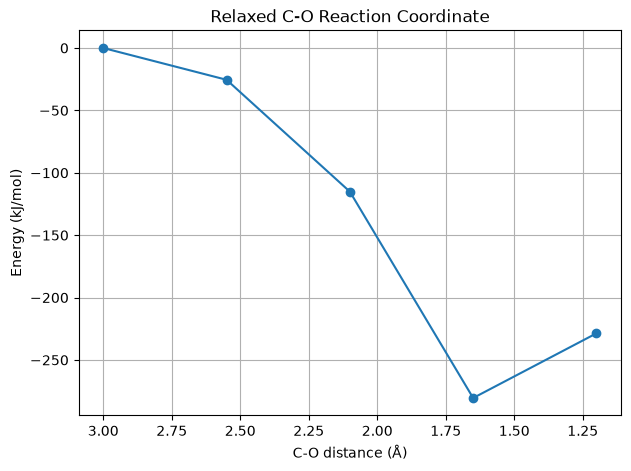

In [10]:
# Looking at the energies
energies_kj=(energies-energies[0])*2626
plt.figure(figsize=(7,5))
plt.plot(actual_distances,energies_kj,marker="o")
plt.gca().invert_xaxis()
xlabel = "C-O distance (Å)"; plt.xlabel(xlabel)
ylabel = "Energy (kJ/mol)"
plt.ylabel(ylabel)
plt.title("Relaxed C-O Reaction Coordinate")
plt.grid(True)
plt.show()

### Saving additional results

In [11]:
# Saves the optimized molecule objects
with open("optimized_mols.pkl", "wb") as f:
    pickle.dump(optimized_molecules, f)

with open("optimized_mfs.pkl", "wb") as f:
    pickle.dump(mean_field_objects, f)
    
# Save the energies as a text file
data = np.array([actual_distances,energies_kj]).T; print(np.shape(data))
np.savetxt('energy.txt',data,header=xlabel+', '+ylabel)

(5, 2)
